In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
path = "../data/raw"

In [40]:
drivers_standings = pd.read_csv(path + "/driver_standings.csv")
drivers_standings.head()
#Probably the most important table for understanding the championship standings. Can be helpful for finding the total points for each driver.

,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


In [86]:
top30_drivers_by_points = drivers_standings.groupby("driverId").sum()["points"].sort_values(ascending=False)[:30].reset_index()

top30_drivers_by_points = pd.merge(top30_drivers_by_points, drivers, how="left", left_on="driverId", right_on="driverId")[["driverId", "points", "forename", "surname"]]
labels = (top30_drivers_by_points["forename"] + " " + top30_drivers_by_points["surname"])

In [85]:
point_distribution = {
    1: 25,
    2: 18,
    3: 15,
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1
}

drivers_standings_recalculated = drivers_standings.copy()

drivers_standings_recalculated["modern_points"] = drivers_standings_recalculated["position"].map(point_distribution).fillna(0)

top30_drivers_by_points_recalculated = drivers_standings_recalculated.groupby("driverId").sum()["modern_points"].sort_values(ascending=False)[:30].reset_index()

top30_drivers_by_points_recalculated = pd.merge(top30_drivers_by_points_recalculated, drivers, how="left", left_on="driverId", right_on="driverId")[["driverId", "modern_points", "forename", "surname"]]

labels_recalculated = (top30_drivers_by_points_recalculated["forename"] + " " + top30_drivers_by_points_recalculated["surname"]) 

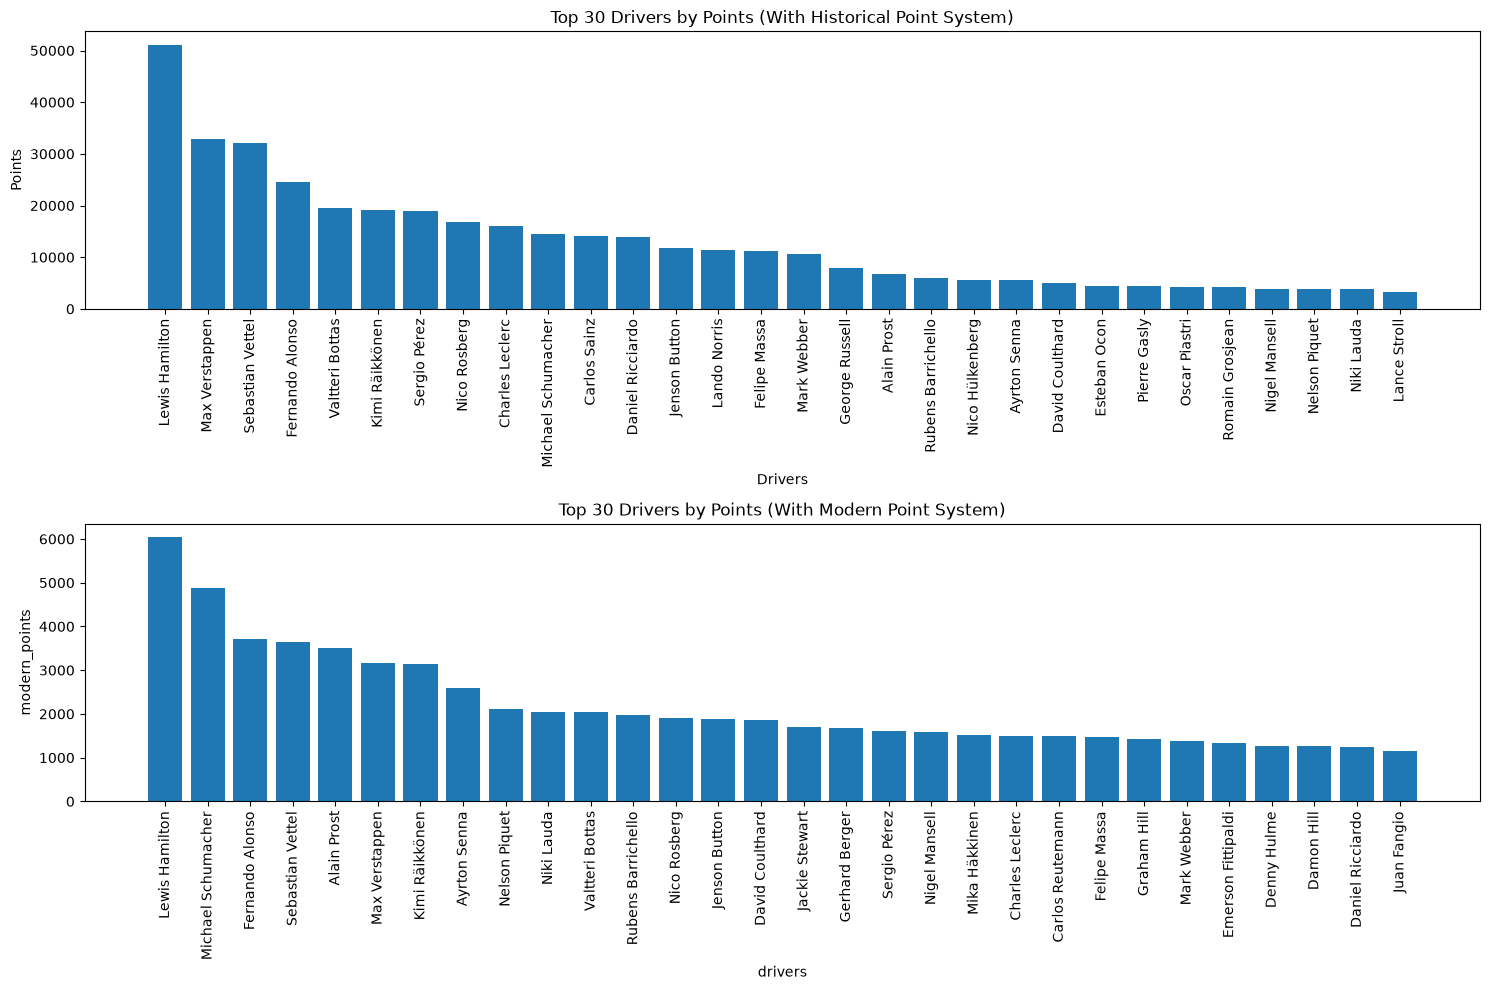

In [94]:

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].bar(labels, top30_drivers_by_points["points"])
axes[0].set_xlabel("Drivers")
axes[0].set_ylabel("Points")
axes[0].set_title("Top 30 Drivers by Points (With Historical Point System)")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(labels_recalculated, top30_drivers_by_points_recalculated["modern_points"])
axes[1].set_xlabel("drivers")
axes[1].set_ylabel("modern_points")
axes[1].set_title("Top 30 Drivers by Points (With Modern Point System)")
axes[1].tick_params(axis="x", rotation=90)

fig.tight_layout()
plt.savefig(
    "../reports/figures/driver_points_modern_vs_historical.png",
    bbox_inches="tight"
)

Although, second table is more accurate it still does not account for the differences in race number per season. Modern f1 seasons generally have more races than earlier seasons, meaning that the table is not as directly comparable as it may initially appear. However this table still shows the consistency of particular drivers.